# KND_04 — Notebook 9: Understand our results

**Main question:** Where does our current model make mistakes, and what do those mistakes mean?

We use the predictions already saved in Notebook 8. We do not train again, change the 0.20 cutoff or choose a different model. This is a closer look at the **same test results**, not a new independent test.

## Start here

1. Open this notebook in Colab.
2. Upload **KND_04_Step9_Input_Files.zip** in the Files panel.
3. Choose **Runtime → Run all**.
4. Download **KND_04_Step9_Results.zip** at the end.

This bundle matches our checked Notebook 8 run. It contains saved predictions, supporting data and a readable helper file. **It does not load the saved model**, so you do not need the exact model-library versions from Notebook 8. Normal pandas, numpy and matplotlib are enough. If an import is missing, use `%pip install pandas numpy matplotlib` in a separate cell.

Each section has a simple sentence you can use in the viva. The helper file contains the longer file checks, counting and saving functions. It is included so you can inspect it.

**Important:** Understanding poor results is part of the project. Do not change or hide the results to make the model look better.

## 1. Open the files — setup only

**Say this:** “We opened the saved predictions and the details needed to review them.”

In [1]:
from pathlib import Path
from zipfile import ZipFile
import sys, json
locations = [Path.cwd(), Path.cwd() / "outputs", Path("/content")]
zip_path = next((p / "KND_04_Step9_Input_Files.zip" for p in locations
                 if (p / "KND_04_Step9_Input_Files.zip").is_file()), None)
if zip_path is not None:
    with ZipFile(zip_path) as archive:
        names = archive.namelist()
        assert len(names) == len(set(names)) == 10
        assert all(len(Path(n).parts) == 2 and Path(n).parts[0] == "step9_inputs" and ".." not in Path(n).parts for n in names)
        archive.extractall(zip_path.parent)
INPUT_DIR = next((p / "step9_inputs" for p in locations
                  if (p / "step9_inputs/input_manifest.json").is_file()), None)
if INPUT_DIR is None:
    raise FileNotFoundError("Upload KND_04_Step9_Input_Files.zip first.")
INPUT_DIR = INPUT_DIR.resolve()
sys.path.insert(0, str(INPUT_DIR))
print("Input folder:", INPUT_DIR)

Input folder: C:\Users\ishin\Documents\Codex\2026-09-15\we-x20\outputs\step9_inputs


## 2. Load and check the saved results

We match records using their source row number, animal ID, date and target. We check that the saved predictions still use the original cutoff.

**Say this:** “We checked that the predictions match the correct animal admissions.”

In [2]:
import importlib
sys.modules.pop("step9_helpers", None)
importlib.invalidate_caches()
import step9_helpers as helper
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = helper.load_records(INPUT_DIR)
notes = json.loads((INPUT_DIR / "final_test_notes.json").read_text())
RESULTS_DIR = INPUT_DIR.parent / "step9_results"
RESULTS_DIR.mkdir(exist_ok=True)
print("Records checked:", len(data))
print("Saved cutoff:", notes["threshold"])
print("No model is trained or loaded here.")

Records checked: 1672
Saved cutoff: 0.2
No model is trained or loaded here.


## 3. Check the overall result again

The helper counts the four outcomes: correct short stays, false alerts, missed long stays and caught long stays.

- **Precision:** caught long stays ÷ all alerts.
- **Recall:** caught long stays ÷ all actual long stays.
- **False-alert rate:** false alerts ÷ all actual short stays.
- **Alert share:** all alerts ÷ all admissions.

Precision and false-alert rate use **different denominators**. For example, “most alerts were wrong” is different from “most short stays were flagged.”

**Say this:** “We checked the original counts before looking at smaller groups.”

In [3]:
overall = helper.count_results(data)
for name in ["correct_short", "false_alerts", "missed_long", "caught_long"]:
    print(name.replace("_", " "), ":", int(overall[name]))
print("Precision:", f"{overall['precision']:.1%}")
print("Recall:", f"{overall['recall']:.1%}")
print("Arrivals flagged:", f"{overall['alert_share']:.1%}")

assert int(overall["false_alerts"]) == notes["counts"]["false_alerts"]
assert int(overall["caught_long"]) == notes["counts"]["caught_long_stays"]
assert int(overall["missed_long"]) == notes["counts"]["missed_long_stays"]
assert int(overall["correct_short"]) == notes["counts"]["true_short"]

correct short : 626
false alerts : 732
missed long : 84
caught long : 230
Precision: 23.9%
Recall: 73.2%
Arrivals flagged: 57.5%


## 4. Compare dogs, cats and other animals

We show the number of records as well as the rates. A larger group can have more mistakes simply because it has more records.

The helper warns when a group has fewer than 30 records or fewer than 10 examples of either class. This is a simple caution rule, not a statistical test. A blank/NaN rate means it cannot be calculated, for example precision when there are no alerts.

**Say this:** “We checked each animal group separately. We compared rates as well as counts because the group sizes are different.”

        rows  actual_long  caught_long  missed_long  false_alerts  precision  recall small_group_note
type                                                                                                 
CAT    530.0        124.0        114.0         10.0         251.0      0.312   0.919                 
DOG    950.0        154.0         98.0         56.0         410.0      0.193   0.636                 
OTHER  192.0         36.0         18.0         18.0          71.0      0.202   0.500                 


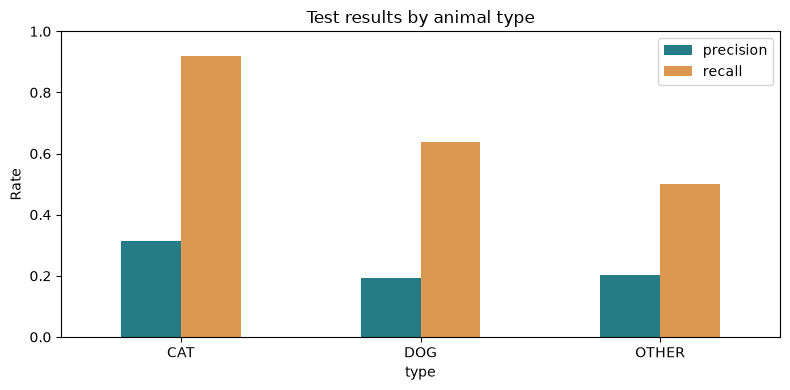

In [4]:
species = helper.compare_groups(data, "type")
columns = ["rows", "actual_long", "caught_long", "missed_long",
           "false_alerts", "precision", "recall", "small_group_note"]
print(species[columns].round(3).to_string())

ax = species[["precision", "recall"]].plot.bar(figsize=(8, 4), color=["#267b87", "#dc9750"])
ax.set(title="Test results by animal type", ylabel="Rate", ylim=(0, 1))
ax.tick_params(axis="x", rotation=0)
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "01_species_results.png", dpi=150)
plt.show()

## 5. Compare available and unavailable ages

We call age unavailable when the birth date is missing, invalid or after the arrival date. These cases already received the training-based age estimate in the saved model. We do not fill ages again here.

**Say this:** “We checked whether results differed when the original age was unavailable. A difference does not prove missing age caused the error.”

In [5]:
birth = pd.to_datetime(data["date_of_birth"], errors="coerce")
arrival = pd.to_datetime(data["intake_date"])
age_unavailable = birth.isna() | (birth > arrival)
data["age_group"] = np.where(age_unavailable, "Age unavailable", "Age available")

age_results = helper.compare_groups(data, "age_group")
print(age_results[columns].round(3).to_string())

                   rows  actual_long  caught_long  missed_long  false_alerts  precision  recall small_group_note
age_group                                                                                                       
Age available    1300.0        292.0        227.0         65.0         611.0      0.271   0.777                 
Age unavailable   372.0         22.0          3.0         19.0         121.0      0.024   0.136                 


## 6. Compare known and unknown intake conditions

Blank or `UNKNOWN` means the condition was not recorded clearly. It does **not** mean healthy. “Recorded condition” can include several different conditions.

**Say this:** “We kept unknown conditions as their own group and checked their results separately.”

In [6]:
condition = data["intake_condition"].fillna("UNKNOWN").str.strip().str.upper()
unknown_condition = condition.isin(["", "UNKNOWN"])
data["condition_group"] = np.where(unknown_condition, "Unknown condition", "Recorded condition")

condition_results = helper.compare_groups(data, "condition_group")
print(condition_results[columns].round(3).to_string())

                      rows  actual_long  caught_long  missed_long  false_alerts  precision  recall small_group_note
condition_group                                                                                                    
Recorded condition   282.0         47.0         47.0          0.0         206.0      0.186   1.000                 
Unknown condition   1390.0        267.0        183.0         84.0         526.0      0.258   0.685                 


## 7. Check completed stays separately

Our original target included some animals with no recorded outcome that had already stayed more than 30 days. We assumed those stays were ongoing.

Here we keep only records with a recorded completed stay, then review the **same saved predictions**. We show the excluded ongoing group too, so the difference is transparent.

This is a **sensitivity check**: does our summary change when we leave out the assumption-based labels? It is not a new test, and it does not tell us whether those assumed labels were correct. Completed cases are a different mix of animals and may exclude difficult long stays. Do not replace the original full-test result with whichever subset looks better.

**Say this:** “We checked completed stays separately because some original long-stay labels were based on the ongoing-stay assumption.”

In [7]:
completed = data.loc[data["label_source"].eq("Recorded completed stay")]
ongoing = data.loc[~data["label_source"].eq("Recorded completed stay")]
completed_check = pd.DataFrame({
    "All test admissions": overall,
    "Completed admissions only": helper.count_results(completed),
    "Assumed ongoing admissions": helper.count_results(ongoing)
}).T

print(completed_check[["rows", "actual_long", "caught_long", "missed_long",
                       "false_alerts", "precision", "recall"]].round(3).to_string())
assert len(completed) + len(ongoing) == len(data)

                              rows  actual_long  caught_long  missed_long  false_alerts  precision  recall
All test admissions         1672.0        314.0        230.0         84.0         732.0      0.239   0.732
Completed admissions only   1578.0        220.0        161.0         59.0         732.0      0.180   0.732
Assumed ongoing admissions    94.0         94.0         69.0         25.0           0.0      1.000   0.734


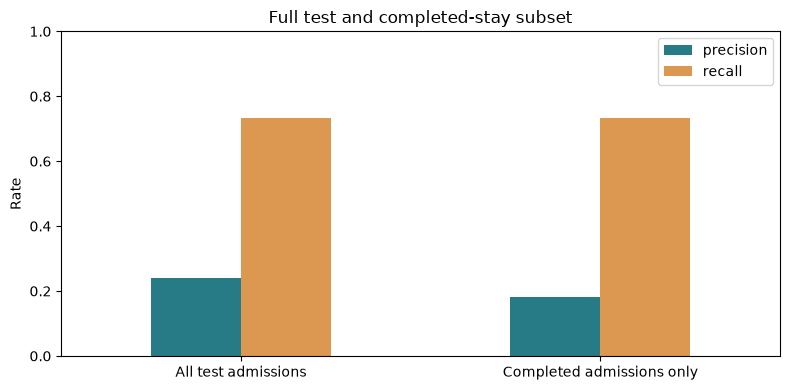

In [8]:
ax = completed_check.iloc[:2][["precision", "recall"]].plot.bar(
    figsize=(8, 4), color=["#267b87", "#dc9750"])
ax.set(title="Full test and completed-stay subset", ylabel="Rate", ylim=(0, 1))
ax.tick_params(axis="x", rotation=0)
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "02_completed_stay_check.png", dpi=150)
plt.show()

## 8. Check how the class balance changed over time

The training, validation and test periods can contain different shares of long stays. This is one possible influence on precision and average precision. It does not explain all performance differences or prove why they happened.

**Say this:** “The later data had a different mix of short and long stays, so performance did not have to match the earlier periods.”

            rows  actual_long  long_share
split                                    
Training    6096         1912      0.3136
Validation  1163          245      0.2107
Test        1672          314      0.1878


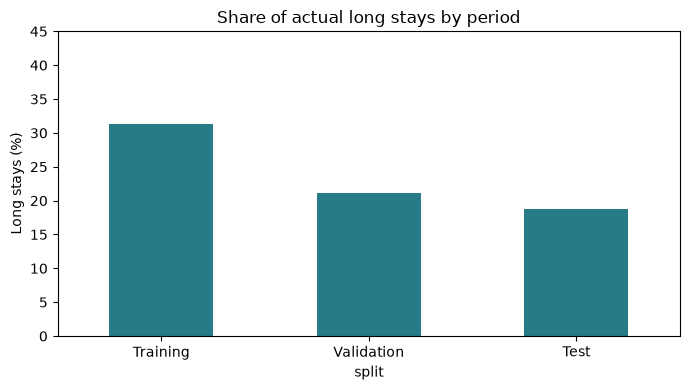

In [9]:
periods = helper.compare_periods(INPUT_DIR)
print(periods.round(4).to_string())

ax = (periods["long_share"] * 100).plot.bar(figsize=(7, 4), color="#267b87")
ax.set(title="Share of actual long stays by period", ylabel="Long stays (%)", ylim=(0, 45))
ax.tick_params(axis="x", rotation=0)
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "03_class_balance.png", dpi=150)
plt.show()

## 9. Be ready to explain why Random Forest was selected

In Notebook 7 we fixed a rule: choose the highest mean average precision across **three checks inside training**. Random Forest won that comparison. Gradient Boosting scored higher on the later external validation ranking. The table below shows both facts.

The cutoff was then chosen using validation F2. F2 favours catching long stays, which helps explain the number of false alerts. We have not agreed that workload with shelter staff.

The historical training-check score and later validation score are measured on different periods. The gap is a reason for caution. It is not proof of a single cause, and the small gap between the top training candidates does not prove a significant difference.

**Say this:** “We chose Random Forest using the comparison rule set before the later validation results. It did not win every measure, and we report that honestly.”

In [10]:
cv = pd.read_csv(INPUT_DIR / "cv_summary.csv")
validation = pd.read_csv(INPUT_DIR / "validation_comparison.csv")
winners = cv.sort_values("rank").drop_duplicates("family")
selection_review = winners[["family", "candidate_id", "mean_ap", "std_ap"]].merge(
    validation[["candidate_id", "average_precision", "selected_by_cv"]],
    on="candidate_id", validate="one_to_one")
print(selection_review.round(4).to_string(index=False))

             family                   candidate_id  mean_ap  std_ap  average_precision  selected_by_cv
      random_forest       random_forest_2_ordinary   0.6770  0.0767             0.3585            True
  gradient_boosting   gradient_boosting_3_balanced   0.6701  0.0881             0.3718           False
logistic_regression logistic_regression_1_ordinary   0.6424  0.0651             0.3513           False
      decision_tree       decision_tree_3_ordinary   0.5908  0.0728             0.3397           False


## 10. Explain what the alerts mean for staff

A false alert is not automatically a serious harm, but it uses review time. A missed long stay means a potentially useful early review was not triggered. Our data does not tell us how much either mistake costs.

**Say this:** “The model could suggest cases for staff review, but the number of false alerts is a practical limitation. We have not shown a real-world benefit yet.”

In [11]:
alerts = int(overall["caught_long"] + overall["false_alerts"])
wrong_alert_share = overall["false_alerts"] / alerts if alerts else np.nan
print("Alerts requiring review:", alerts)
print("Alerts that were actually long stays:", int(overall["caught_long"]))
print("Alerts that were actually short stays:", int(overall["false_alerts"]))
print("Share of alerts that were wrong:", f"{wrong_alert_share:.1%}")
print("These counts describe this test period, not a future daily workload.")

Alerts requiring review: 962
Alerts that were actually long stays: 230
Alerts that were actually short stays: 732
Share of alerts that were wrong: 76.1%
These counts describe this test period, not a future daily workload.


## 11. Four-member speaking guide

Read this aloud and use the tables above to give one real example. Only claim contributions you actually made. Everyone should understand the whole workflow.

In [12]:
speech = helper.make_speech(overall, completed_check.loc["Completed admissions only"], species)
print(speech)

KND_04 - Notebook 9: explaining results and limitations

Member 1: Purpose and method
"We used the predictions already saved in Notebook 8. We did not train again,
change the model, or change its 0.20 cutoff. We checked the mistakes in more
detail so we could explain where the current model struggles."

Member 2: Results by animal type
"We compared dogs, cats and other animals. For each group, we counted actual
long stays, caught long stays, missed cases and false alerts. We compared
rates as well as counts because the groups have different sizes. A difference
does not prove that animal type caused the mistake or that the model is fair."

Member 3: Missing information and label assumptions
"We compared records with available and unavailable ages, and known and
unknown intake conditions. Unknown does not mean healthy. Then we looked
at completed stays separately. There were 1578 completed admissions,
with 220 long stays. The model caught 161 and missed
59 of those long stays. This is a 

## 12. Save and download

The ZIP contains the group comparisons, completed-stay check, class balance, model-selection comparison, charts, joined records, limitations and **viva_speaking_guide.txt**.

Refresh the Colab Files panel and download **KND_04_Step9_Results.zip**. The files from Notebooks 7 and 8 remain unchanged.

In [13]:
tables = {
    "overall_counts_and_rates": overall.to_frame("value"),
    "results_by_animal_type": species,
    "results_by_age_availability": age_results,
    "results_by_condition_availability": condition_results,
    "completed_only_check": completed_check,
    "class_balance_by_period": periods,
    "model_selection_review": selection_review
}
helper.save_outputs(INPUT_DIR, RESULTS_DIR, tables, data, speech)

Input fingerprints still match. No model or cutoff was changed.
Results: C:\Users\ishin\Documents\Codex\2026-09-15\we-x20\outputs\step9_results
Download: C:\Users\ishin\Documents\Codex\2026-09-15\we-x20\outputs\KND_04_Step9_Results.zip


## Short questions for Progress Evaluation 2

**What is the difference between Notebook 8 and Notebook 9?**
“Notebook 8 measured the final test performance. Notebook 9 looks more closely at those same results.”

**Did you change the model after seeing the test results?**
“No. We kept the model and cutoff fixed.”

**Does a worse result for one group prove bias?**
“No. We must consider group size, the share of long stays and other differences. Our comparison is descriptive, not proof of fairness or unfairness.”

**Why check completed stays separately?**
“Some labels assume that animals with missing outcomes were still staying. We checked the completed subset to understand how that assumption affects the reported results.”

**Can we report only the better subset?**
“No. We keep the full-test result and clearly label the subset check.”

**Why not change the cutoff now to reduce false alerts?**
“That would use test answers for development. We would need fresh independent evaluation for the changed system.”

**Does this notebook explain why a particular animal received a score?**
“No. It compares errors across groups. We have not calculated individual feature explanations here.”

**What remains?**
“Association rules promised in our proposal, the application, system testing, report and final presentation. We also need to practise explaining our own contributions.”

**Scope reminder:** this describes Sonoma County, California, USA. It does not show how the model would perform in Sri Lanka. No new algorithm, calibration, feature selection, causal analysis or significance test was performed in this notebook.